# Diabetes Risk Factor Analysis
## Reproducibility Exercise — Starter Notebook

You are a **data scientist at a teaching hospital within a multi-site academic health system**. This preliminary analytical notebook was originally developed for internal exploratory analysis. The **Data Science Director** has asked you to prepare the notebook and supporting files for sharing with the data science team at another clinical site.

The receiving team should be able to obtain the project files, understand the workflow, execute the notebook in its own computational environment, and reproduce the intended results **without contacting you for additional guidance**.

Review the entire notebook, address all embedded **DATA SCIENCE DIRECTOR NOTE** items, identify and resolve additional reproducibility problems, improve the documentation and organization, and verify the final workflow from a clean runtime.

#### Connection to Upcoming Coursework and Final Project

This exercise is an important step in the development of your final project workflow. The reproducibility, documentation, notebook organization, and programming practices you apply in this assignment will build upon your prior Python programming work and serve as a foundation for the Week 3 Automated Analysis Pipeline Exploration assignment.

In Week 3, you will work with a more advanced automated analytical pipeline that incorporates conditional logic, inferential statistical methods, supervised machine learning, model evaluation, and automated analytical decision-making. Many of the practices reinforced in this exercise—including modular programming, reproducible execution, clear Markdown documentation, dependency management, data validation, and logical workflow organization—will be expected in that assignment.

Your work across these assignments will also inform the development of your final project notebook, in which you will adapt and extend a comprehensive example analytical pipeline for your selected dataset.

Complete this exercise thoroughly and with your final project in mind. The goal is not simply to correct the issues identified in the starter notebook, but to develop programming, documentation, and reproducibility practices that you can carry forward into increasingly complex analytical workflows throughout the remainder of the course.

---

# Diabetes Risk Factor Analysis

This notebook explores how patient measurements (glucose, BMI, age, and others) relate to a diabetes diagnosis. It is written so a data science team at another clinical site can run it start to finish and get the same results, then reuse it as a template for their own patient data.

**Workflow:** Setup → Data Source → Data Review → Descriptive Statistics → Visualizations → Inferential Analysis → Problem Formulation → Reproducibility → Results

**How to run:** Follow the setup steps below, then choose **Restart and Run All**. Cells depend on the ones above them, so run them in order.

## Setup and Environment

The analysis uses common Python data science libraries.

**Requirements:** Python 3.11 or newer. The required packages and their exact versions are listed in `requirements.txt`.

**Steps:**
1. Download or clone the project folder from GitHub.
2. Open a terminal in the project folder and install the packages:
```
   pip install -r requirements.txt
```
3. Open this notebook **from the project folder** (the data file is found using a relative path).
4. Choose **Restart and Run All**.

The next cell imports the libraries used throughout the analysis.

In [1]:
import pandas as pd
import numpy as np

## Data Source

The project uses the diabetes example dataset provided with the analysis.

**Dataset:** `Example Dataset_Diabetes.csv`, an example dataset is from the Pima Indians Diabetes Database from the U.S. National Institute of Diabetes and Digestive and Kidney Diseases which includes adult women of Pima Indian heritage. This is an example data used to build and test the workflow. It is not patient data from either clinical site.

**How to access the file**: The example dataset is included in this repository at `Example_Dataset_Diabetes.csv`.

In [16]:
df = pd.read_csv("Example_Dataset_Diabetes.csv")
df.head()

,Pregnancies,Glucose,D_BP,Skin_Thickness,Insulin,BMI,Pedigree,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## Initial Data Review

Before analyzing anything, we confirm that the expected dataset was loaded. The cell below prints the shape, missing values, and data types, then uses `assert` checks that stop the notebook with an error if something is wrong: the file must have 768 rows and 9 columns, the expected column names, and an `Outcome` column containing only 0 and 1.

**If a check fails:** the wrong file or a modified file was loaded. Re-download the file and confirm the path

In [3]:
print("Shape:", df.shape)
print("\nMissing values:")
print(df.isna().sum())
print("\nData types:")
print(df.dtypes)

assert df.shape == (768, 9), "Unexpected shape"
assert list(df.columns) == ["Pregnancies", "Glucose", "D_BP", "Skin_Thickness",
                            "Insulin", "BMI", "Pedigree", "Age", "Outcome"], "Unexpected columns"
assert set(df["Outcome"].unique()) == {0, 1}, "Outcome must be 0 or 1"
print("\nAll checks passed.")

Shape: (768, 9)

Missing values:
Pregnancies       0
Glucose           0
D_BP              0
Skin_Thickness    0
Insulin           0
BMI               0
Pedigree          0
Age               0
Outcome           0
dtype: int64

Data types:
Pregnancies         int64
Glucose             int64
D_BP                int64
Skin_Thickness      int64
Insulin             int64
BMI               float64
Pedigree          float64
Age                 int64
Outcome             int64
dtype: object

All checks passed.


In [4]:
zero_cols = ["Glucose", "D_BP", "Skin_Thickness", "Insulin", "BMI"]
df[zero_cols] = df[zero_cols].replace(0, np.nan)
df.isna().sum()

Pregnancies         0
Glucose             5
D_BP               35
Skin_Thickness    227
Insulin           374
BMI                11
Pedigree            0
Age                 0
Outcome             0
dtype: int64

**Check:** The columns above scientifically cannot have a 0 value. These values were replaced with N/A to show the most accurate data 

## Descriptive Statistics

The table below summarizes each variable (count, mean, standard deviation, quartiles).

In [5]:
df.describe()

,Pregnancies,Glucose,D_BP,Skin_Thickness,Insulin,BMI,Pedigree,Age,Outcome
count,768.000000,763.000000,733.000000,541.000000,394.000000,757.000000,768.000000,768.000000,768.000000
mean,3.845052,121.686763,72.405184,29.153420,155.548223,32.457464,0.471876,33.240885,0.348958
std,3.369578,30.535641,12.382158,10.476982,118.775855,6.924988,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,64.000000,22.000000,76.250000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,141.000000,80.000000,36.000000,190.000000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


### Mean and Standard Deviation

The mean represents the average value of a variable: 

$$
\bar{x} = \frac{1}{n}\sum_{i=1}^{n} x_i
$$

where:

- $\bar{x}$ = sample mean
- $x_i$ = each individual observation
- n = total number of observations

The standard deviation measures the amount of variability or spread in a set of observations relative to the mean.

$$
s = \sqrt{\frac{\sum_{i=1}^{n}(x_i-\bar{x})^2}{n-1}}
$$

where:

- s = sample standard deviation
- $x_i$ = value for patient $i$
- $\bar{x}$ = mean
- n = number of patients with a recorded value for that variable

In this analysis we compare the mean and standard deviation of patient characteristics between patients **without** diabetes (Outcome = 0) and **with** diabetes (Outcome = 1).

## Visualizations



### Individual variables
The histograms below show the distributions of glucose and BMI

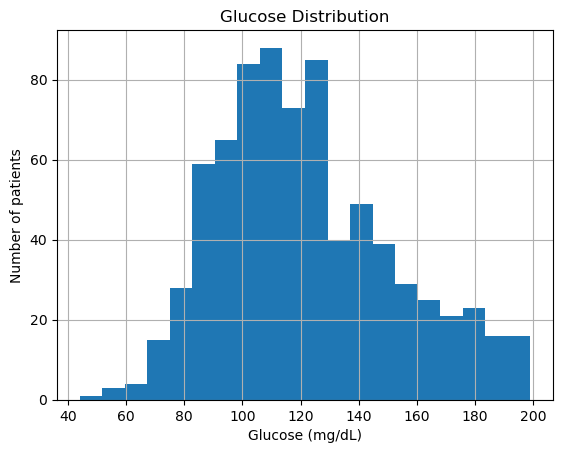

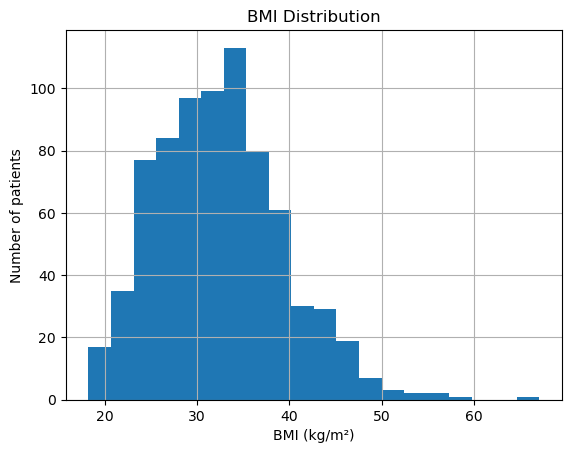

In [6]:
import matplotlib.pyplot as plt

df["Glucose"].hist(bins=20)
plt.title("Glucose Distribution")
plt.xlabel("Glucose (mg/dL)")
plt.ylabel("Number of patients")
plt.show()

df["BMI"].hist(bins=20)
plt.title("BMI Distribution")
plt.xlabel("BMI (kg/m²)")
plt.ylabel("Number of patients")
plt.show()

Glucose is mildly right-skewed, with most patients between about 100 and 135 mg/dL and a tail up toward 200. 
BMI is roughly bell-shaped with a slight right tail and most patients fall between about 25 and 40 kg/m².

### Bivariate: Glucose by diabetes outcome
A box plot compares a numeric variable (glucose) across the two outcome groups.

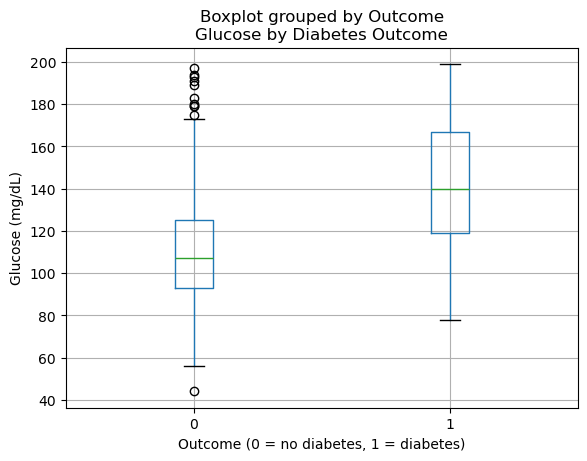

In [7]:
df.boxplot(column="Glucose", by="Outcome")
plt.title("Glucose by Diabetes Outcome")
plt.xlabel("Outcome (0 = no diabetes, 1 = diabetes)")
plt.ylabel("Glucose (mg/dL)")
plt.show()

The median glucose is about 140 mg/dL for patients with diabetes and about 110 mg/dL for patients without, and the box for the diabetes group sits clearly higher. The groups still overlap, and the non-diabetes group has several high outliers, so glucose is strongly associated with diabetes. 

### Bivariate: BMI versus glucose
A scatter plot shows the relationship between two numeric variables.

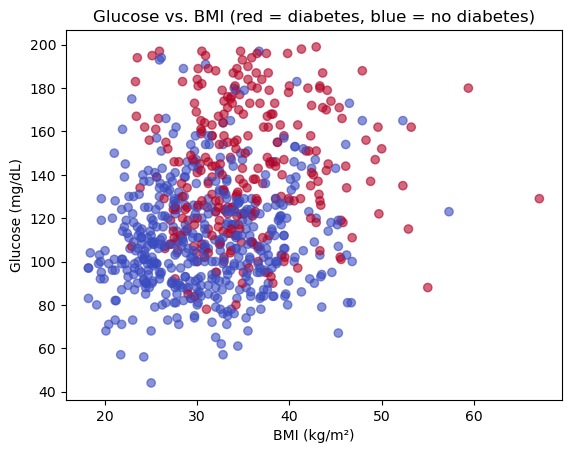

In [8]:
plt.scatter(df["BMI"], df["Glucose"], c=df["Outcome"], cmap="coolwarm", alpha=0.6)
plt.title("Glucose vs. BMI (red = diabetes, blue = no diabetes)")
plt.xlabel("BMI (kg/m²)")
plt.ylabel("Glucose (mg/dL)")
plt.show()

The red (diabetes) points are concentrated at higher glucose values at nearly any BMI, with a smaller shift toward higher BMI. This suggests glucose and BMI each carry some separate information about diabetes.

### Correlation matrix and heatmap
**Method: Spearman rank correlation.** Pearson correlation assumes a roughly linear relationship and is sensitive to skew and outliers. Several variables here are right-skewed (for example Insulin, Age, and Pedigree). Spearman correlation compares ranks, so it handles these features. `Outcome` is included as a 0/1 variable, so its correlations show the rank association between each measurement and diabetes status. Each correlation uses the patients who have values for both variables.

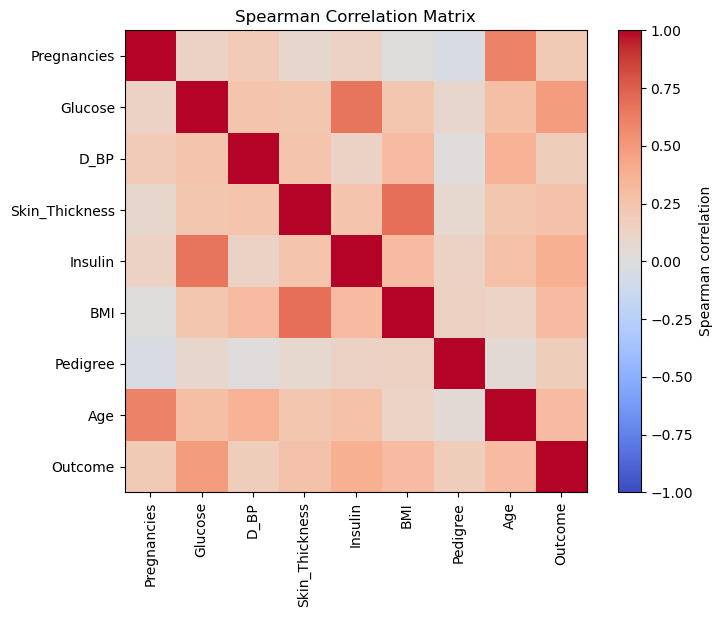

In [9]:
corr = df.corr(method="spearman")

plt.figure(figsize=(8, 6))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Spearman correlation")
plt.xticks(range(len(corr)), corr.columns, rotation=90)
plt.yticks(range(len(corr)), corr.columns)
plt.title("Spearman Correlation Matrix")
plt.show()

**How to read it:** values range from -1 to +1. Positive values (red) mean the two variables tend to rise together, values near 0 (gray) mean no consistent relationship, and negative values (blue) mean one rises as the other falls. The diagonal is always 1.00 because each variable is perfectly correlated with itself.

**Interpretation** (below about 0.3 is weak, 0.3–0.5 moderate, and above 0.5 strong):

- **Glucose and Insulin:** a strong positive relationship. Patients with higher glucose tend to also have higher insulin, which is consistent with how the body regulates blood sugar.
- **Glucose and Outcome (ρ ≈ 0.48):** a moderate positive relationship. Patients with higher glucose values tend to be in the diabetes group, which matches the group difference seen in the box plot and the t-test.
- **Glucose and the other variables:** weak. Age, D_BP, BMI, and Skin_Thickness show only slight positive relationships, and Pregnancies  and Pedigree  show almost none. 

**Relationships among predictors.** Skin_Thickness and BMI are strongly related, which makes sense because both reflect body fat. Age and Pregnancies are also strongly related because older patients have generally had more pregnancies. These overlapping variables carry similar information, which matters for any future model.

## Inferential Analysis

The following analysis compares glucose values between the two outcome groups.

The descriptive statistics and plots suggest that glucose is higher in patients with diabetes. This section tests whether that difference is larger than we would expect by chance, using two methods.

**Purpose:** test whether the mean glucose of patients without diabetes ($\mu_0$) differs from that of patients with diabetes ($\mu_1$):

$$
H_0: \mu_0 = \mu_1 \qquad H_1: \mu_0 \neq \mu_1
$$

**What it evaluates:** the t-statistic compares the difference between the two group means with the variation expected from chance. This version assumes both groups have equal variance:

In [10]:
from scipy.stats import ttest_ind

group_0 = df.loc[df["Outcome"] == 0, "Glucose"].dropna()
group_1 = df.loc[df["Outcome"] == 1, "Glucose"].dropna()

t_stat, p_value = ttest_ind(group_0, group_1)
print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: -15.700907488875874
p-value: 2.4782891993106313e-48


**Result and interpretation:** t ≈ −15.70 with p ≈ 2.5 × 10⁻⁴⁸. The p-value is far below 0.05, so we reject the null hypothesis: mean glucose is significantly higher in patients with diabetes than in patients without. The t-statistic of about −15.7 means the difference in mean glucose between the two groups is roughly 15.7 times larger than would be expected from random variation alone.

**Mann-Whitney U test: glucose by outcome**

**Purpose:** check the same question with a test that does **not** assume glucose is normally distributed or that the two groups have equal variance. The glucose histogram is somewhat right-skewed.

**What it evaluates:** it ranks all glucose values from both groups together and asks whether one group tends to have higher ranks than the other:

$$
U = R_0 - \frac{n_0(n_0+1)}{2}
$$

where $n_0$ is the number of patients without diabetes and $R_0$ is the sum of their ranks. The null hypothesis is that the glucose distributions are the same in both groups.

In [11]:
from scipy.stats import mannwhitneyu

u_stat, u_p = mannwhitneyu(group_0, group_1)
print(u_stat)
print(u_p)

27393.5
1.3050386606170123e-40


**Result and interpretation:** U = 27,393.5 with p ≈ 1.3 × 10⁻⁴⁰. This agrees with the t-test: glucose values tend to be significantly higher in patients with diabetes. 

## Data, Statistics, and the Machine Learning Workflow

### Formalizing the Statistical and Machine Learning Problem

In biostatistics and supervised machine learning, we begin with a dataset consisting of observations (examples) and their corresponding target labels. We denote the dataset as:

$$
\mathcal{D} = \{(x_i,y_i)\}_{i=1}^{n},
\qquad
x_i \in \mathbb{R}^{p},
\qquad
y_i \in \{0,1\}.
$$

where:

- $\mathcal{D}$ is the diabetes dataset used in this notebook
- $n$ is the total number of patients (rows)
- $i$ represents the index of a patient, where $i = 1,2,\ldots,n$.
- $x_i$ is the number of predictor varaibles corresponding to the $i^{th}$ observation.
- $p$ (or 8) is the total number of predictor variables.
- $\mathbb{R}^{p}$ denotes the $8$-dimensional real-valued feature space.
- $y_i$ is the feature vector for patient $i$.
- $\{0,1\}$ indicates that this is a diabetes outcome problem, where:
  - $0$ no diabetes
  - $1$ diabetes

For the diabetes dataset used in this notebook:

$$
x_i =
\begin{bmatrix}
\text{Pregnancies} \\
\text{Glucose} \\
\text{D\_BP} \\
\text{Skin\_Thickness} \\
\text{Insulin} \\
\text{BMI} \\
\text{Pedigree} \\
\text{Age}
\end{bmatrix},
\qquad
y_i = \text{Outcome}.
$$

Thus, each observation is represented by a vector of predictor variables, and the machine learning algorithm learns an estimated prediction function:

$$
\hat{f}: \mathbb{R}^{p} \rightarrow \{0,1\},
$$

where:

- $\hat{f}$ (pronounced *"f-hat"*) denotes the **estimated prediction function** learned from the training data.
- The "hat" indicates that the function is an **estimate** of the unknown relationship between the predictor variables and the target variable.

The function $\hat{f}(\cdot)$ maps an observation's predictor variables to a predicted class label.

The objective of supervised learning is to estimate the function $\hat{f}(\cdot)$ so that it accurately predicts the target variable for observations that were **not** used during model training.

## Reproducibility Check


**Problem found:** the original sample and bootstrap calculations used random number generation with no fixed seed. Each time the notebook ran, a different set of patients was sampled and a different bootstrap mean BMI was produced, so results changed between runs.

**Fix:** we define a random seed (`SEED = 42`) and pass it to each random step: `random_state` for the sample, and a seeded random number generator for the bootstrap. The same seed always produces the same "random" draws, so results are identical across runs and across computers.

In [19]:
SEED = 42
# A small participant sample used during review
df.sample(8, random_state=SEED)

,Pregnancies,Glucose,D_BP,Skin_Thickness,Insulin,BMI,Pedigree,Age,Outcome
668,6,98,58,33,190,34.0,0.430,43,0
324,2,112,75,32,0,35.7,0.148,21,0
624,2,108,64,0,0,30.8,0.158,21,0
690,8,107,80,0,0,24.6,0.856,34,0
473,7,136,90,0,0,29.9,0.210,50,0
204,6,103,72,32,190,37.7,0.324,55,0
97,1,71,48,18,76,20.4,0.323,22,0
336,0,117,0,0,0,33.8,0.932,44,0


In [18]:
# Bootstrap estimate used during exploratory review
rng = np.random.default_rng(SEED)
bmi = df["BMI"].dropna()
bootstrap_mean_bmi = df["BMI"].sample(n=len(df), replace=True).mean()
print("Bootstrap mean BMI:", bootstrap_mean_bmi)

Bootstrap mean BMI: 32.21848958333334


**Check:** The bootstrap mean BMI is about 32.20 every time. Run both cells twice to confirm the output does not change. A bootstrap mean is a re-sampled estimate of the average BMI, so it will be close to, but not exactly equal to, the observed mean.

## Results and Conclusions

Add a concise summary of the major analytical findings and any important limitations.

**Key findings** 
- **Data quality:** the file has no blank values, but zeros in Insulin (374 patients), Skin_Thickness (227), D_BP (35), BMI (11), and Glucose (5) represent unmeasured values. These were converted to missing values before analysis.
- **Glucose differs sharply by outcome:** the mean is about 142 mg/dL in patients with diabetes versus 111 mg/dL without. Both the t-test (t ≈ −15.70) and the Mann-Whitney test give p < 10⁻⁴⁰.
- **Correlations:** glucose has the strongest rank correlation with diabetes (ρ ≈ 0.48). Insulin , BMI , and Age follow. Glucose is also strongly correlated with Insulin.
- **Overlapping predictors:** BMI–Skin_Thickness (ρ ≈ 0.69) and Age–Pregnancies (ρ ≈ 0.61) are strongly related, so those variables carry overlapping information.
- **Reproducibility:** all random steps use a fixed seed, so results are identical across runs.

**Limitations**
- **Missing data:** Insulin (about 49% missing) and Skin_Thickness (about 30% missing) limit conclusions about those variables.
- **One population:** the example data come from one specific group of patients, so results at another clinical site may differ.